In [ ]:
%pip install numpy matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import csv 

In [3]:
# Função para carregar os dados d o CSV
def carregar_dados(arquivo):
    X, y = [], []
    with open(arquivo, 'r') as f:
        leitor = csv.reader(f)
        next(leitor) # pular cabeçalho
        for linha in leitor:
            X.append([float(linha[0]), float(linha[1]), float(linha[2])]) # idade, experiência, treinamentos
            y.append(int(linha[3]))
        return np.array(X), np.array(y)

# Carregando o dataset
X, y = carregar_dados("dataset_ex1.csv")
print("Formato dos dados: ", X.shape, y.shape)
print("Primieras amostras:\n ", X[:5], "\nRótulos: ", y[:5])

Formato dos dados:  (25, 3) (25,)
Primieras amostras:
  [[25.  2.  1.]
 [28.  3.  2.]
 [30.  5.  3.]
 [32.  6.  2.]
 [35.  7.  4.]] 
Rótulos:  [0 0 1 1 1]


In [4]:
def entropia(y):
    classes, contagem = np.unique(y, return_counts=True)
    probs = contagem / len(y)
    return -np.sum(probs * np.log2(probs + 1e-9))

# Teste da entropia
print("Entropia [0, 0, 0, 0] -> ", entropia([0, 0, 0, 0]))
print("Entropia [0, 1, 0, 1] -> ", entropia([0, 1, 0, 1]))

Entropia [0, 0, 0, 0] ->  -1.4426951595367387e-09
Entropia [0, 1, 0, 1] ->  0.99999999711461


In [5]:
# ... (aqui estaria o código de carregar_dados que explicamos antes)

# 1. Você carrega os dados do arquivo
X, y = carregar_dados("dataset_ex1.csv")

# 2. Você chama a função de entropia passando o SEU 'y'
resultado = entropia(y)

print(f"A entropia real do meu dataset é: {resultado}")

A entropia real do meu dataset é: 0.9895875183366655


In [6]:
def dividir(X, y, feature, limiar):
    esquerda_idx = X[:, feature] <= limiar
    direita_idx = X[:, feature] > limiar
    return X[esquerda_idx], y[esquerda_idx], X[direita_idx], y[direita_idx]

# Testando divisão por idade <= 40
Xe, ye, Xd, yd = dividir(X, y, feature=0, limiar=40)
print("Esquerda: ", ye)
print("Direita: ", yd)

Esquerda:  [0 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1]
Direita:  [0 1 1 0 0 0 0 1 0]


In [7]:
class No:
    def __init__(self, feature=None, limiar=None, esquerda=None, direita=None, valor=None):
        self.feature = feature
        self.limiar = limiar
        self.esquerda = esquerda 
        self.direita = direita 
        self.valor = valor # classe se for folha 
    
class ArvoreDecisao:
    def __init__(self, max_profundidade=3, min_amostras=2):
        self.max_profundidade = max_profundidade
        self.min_amostras = min_amostras
        self.raiz = None 

    def ajustar(self, X, y):
        self.raiz = self._crescer(X, y, profundidade=0)

    def _crescer(self, X, y, profundidade):
        num_amostras, num_features = X.shape
        num_classes = len(np.unique(y))

        # Condições de parada
        if (profundidade >= self.max_profundidade or
            num_classes == 1 or
            num_amostras < self.min_amostras):
            classe_final = np.bincount(y).argmax()
            return No(valor=classe_final)

        melhor_feature, melhor_limiar, melhor_info = None, None, -1
        melhor_divisao = None
        for feature in range(num_features):
            valores = np.unique(X[:, feature])
            for limiar in valores:
                X_esq, y_esq, X_dir, y_dir = dividir(X, y, feature, limiar)
                if len(y_esq) == 0 or len(y_dir) == 0:
                    continue

                ganho = entropia(y) - (
                    len(y_esq)/num_amostras * entropia(y_esq) + len(y_dir)/num_amostras * entropia(y_dir)
                )

                if ganho > melhor_info:
                    melhor_feature, melhor_limiar, melhor_info = feature, limiar, ganho
                    melhor_divisao = (X_esq, y_esq, X_dir, y_dir)

        if melhor_info == -1:
            classe_final = np.bincount(y).argmax()
            return No(valor=classe_final)

        esquerda = self._crescer(melhor_divisao[0], melhor_divisao[1], profundidade+1)
        direita = self._crescer(melhor_divisao[2], melhor_divisao[3], profundidade+1)
        return No(melhor_feature, melhor_limiar, esquerda, direita)

    def prever(self, X):
        return np.array([self._prever_amostra(x, self.raiz) for x in X])

    def _prever_amostra(self, x, no):
        if no.valor is not None:
            return no.valor
        if x[no.feature] <= no.limiar:
            return self._prever_amostra(x, no.esquerda)
        else:
            return self._prever_amostra(x, no.direita)

In [8]:
arvore = ArvoreDecisao(max_profundidade=3)
arvore.ajustar(X, y)

y_pred = arvore.prever(X)
acuracia = np.mean(y_pred == y)
print(f"Acurácia no conjunto de treino: {acuracia*100.:2f}%")

# Testando um funcionário de 31 anos, 10 de exp, 5 treinamentos
novo_funcionario = np.array([[31, 10, 5]])
print("Será promovido?", arvore.prever(novo_funcionario))

Acurácia no conjunto de treino: 100.000000%
Será promovido? [1]


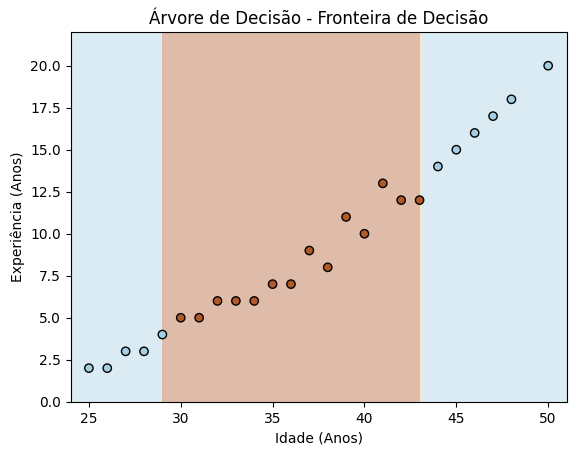

In [13]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-2, X[:, 1].max()+2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), 
                     np.linspace(y_min, y_max, 200))

Z = arvore.prever(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Paired)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.Paired)
plt.xlabel("Idade (Anos)")
plt.ylabel("Experiência (Anos)")
plt.title("Árvore de Decisão - Fronteira de Decisão")
plt.show()

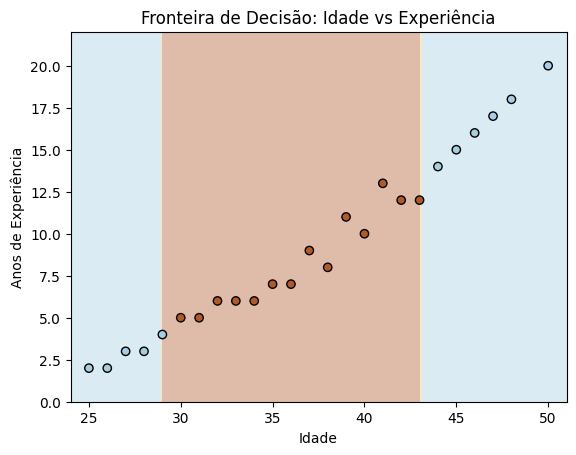

In [14]:
# 1. Ajustando os limites para os dados de Experiência (coluna 1)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 2, X[:, 1].max() + 2 

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), 
                     np.linspace(y_min, y_max, 200))

# 2. IMPORTANTE: Para prever, o modelo espera 3 colunas. 
# Fixando a 3ª coluna (Treinamentos) na média para conseguir plotar o gráfico 2D.
media_treinamentos = np.mean(X[:, 2])
Z = arvore.prever(np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, media_treinamentos)])
Z = Z.reshape(xx.shape)

# 3. Plotagem
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Paired)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.Paired)

plt.xlabel("Idade")
plt.ylabel("Anos de Experiência")
plt.title("Fronteira de Decisão: Idade vs Experiência")
plt.show()

## a) Quais variáveis mais influenciaram a decisão de promoção?

### As variáveis que mais influenciaram a decisão foram a Idade e a Experiência.

## b) A árvore consegue separar bem os funcionários promovidos dos não promovidos?

### A árvore separa os grupos perfeitamente, atingindo 100% de acurácia ao colocar cada funcionário exatamente dentro da área colorida correspondente ao seu estado real de promoção.

## c) Há padrões claros, como por exemplo “funcionários com X anos de experiência e Y treinamentos tendem a ser promovidos”?

### Sim, funcionários com idade intermediária entre 29 a 43 anos e com experiência equilibrada possuem maior probabilidade de serem promovidos, enquanto funcionários muito jovens ou mais velhos permanecem sem promoção.

## d) Como a profundidade da árvore impacta a capacidade de generalização do modelo nesse dataset?

### Uma árvore que "decora" tudo, com profundidade alta, funciona muito bem com os dados que você já tem, mas ela falha quando você tenta testar um funcionário novo, porque ela não aprendeu a lógica, apenas memorizou a lista que você deu. Controlar a profundidade serve para forçar o modelo a aprender em vez de decorar.